Informações da simulação: {'a': 1.0, 'mesh_shape': (256, 256, 256), 'box_size': 512.0}


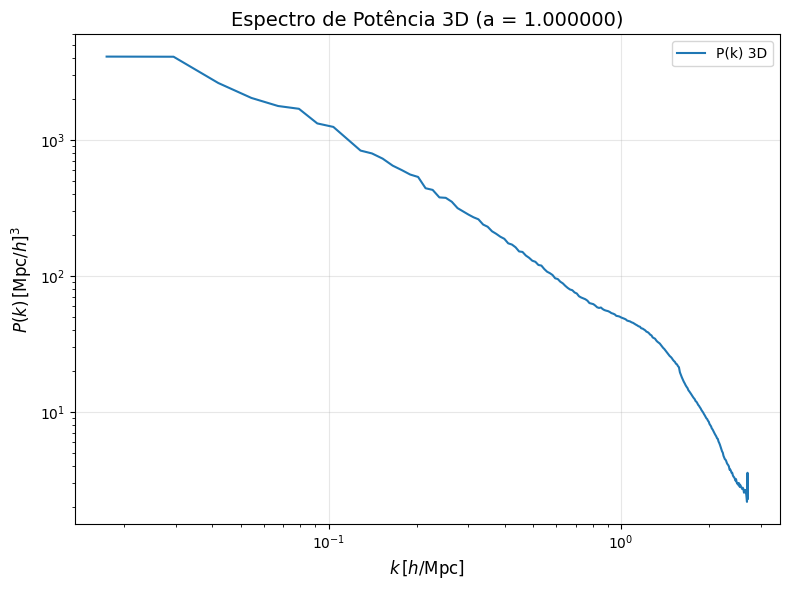

In [1]:
# Célula 1: Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import Pk_library as Pk

# Célula 2: Carregar dados da simulação
data_dir = 'phase_space_data'
a_str = '1.000000'

# Carregar informações da simulação
info = {}
with open(os.path.join(data_dir, f'info_a_{a_str}.txt'), 'r') as f:
    for line in f:
        if '=' in line:
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip()
            if key == 'mesh_shape':
                # Converte (256, 256, 256) para tupla
                value = tuple(map(int, value.strip('()').split(', ')))
            elif key in ['a', 'box_size']:
                value = float(value)
            info[key] = value

print(f"Informações da simulação: {info}")
box_size = info['box_size']  # Em Mpc/h
mesh_shape = info['mesh_shape']

# Célula 3: Plotar espectro 3D já computado pelo Pylians
pk_file = os.path.join(data_dir, f'pk3d_pylians_a_{a_str}.txt')
k_pk = np.loadtxt(pk_file)
k, Pk_3D = k_pk[:,0], k_pk[:,1]

plt.figure(figsize=(8,6))
plt.loglog(k, Pk_3D, '-', label='P(k) 3D')
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$', fontsize=12)
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}/h]^3$', fontsize=12)
plt.title(f'Espectro de Potência 3D (a = {a_str})', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
print(Pk_3D)


[4.121755e+03 4.112566e+03 2.634772e+03 2.045980e+03 1.784497e+03
 1.702423e+03 1.328799e+03 1.252396e+03 1.013113e+03 8.387315e+02
 7.988895e+02 7.316829e+02 6.498083e+02 6.027674e+02 5.590145e+02
 5.364001e+02 4.431433e+02 4.307766e+02 3.793507e+02 3.766000e+02
 3.523829e+02 3.164079e+02 2.990104e+02 2.837803e+02 2.710025e+02
 2.618212e+02 2.394948e+02 2.307438e+02 2.137108e+02 2.046497e+02
 1.948677e+02 1.881101e+02 1.743030e+02 1.706686e+02 1.630172e+02
 1.519093e+02 1.505721e+02 1.416843e+02 1.363627e+02 1.298411e+02
 1.274276e+02 1.207822e+02 1.195514e+02 1.127194e+02 1.077406e+02
 1.051263e+02 1.019180e+02 9.634867e+01 9.514954e+01 9.094637e+01
 8.844280e+01 8.483013e+01 8.191048e+01 7.972332e+01 7.874753e+01
 7.581177e+01 7.447905e+01 7.107493e+01 6.962752e+01 6.855490e+01
 6.757857e+01 6.597436e+01 6.334328e+01 6.273058e+01 6.219015e+01
 6.068991e+01 5.895633e+01 5.831818e+01 5.874421e+01 5.720441e+01
 5.621348e+01 5.566956e+01 5.526605e+01 5.448515e+01 5.343357e+01
 5.295312e

In [ ]:
def phase_space_variations(modes, cosmo, conf, variation=0.5, 
    n=5, output_dir='phase_space_variations', random_seed=1):
    """
    Faz varias simulacoes, variando aleatoriamente dentro de um intervalo de acordo com a cosmologia base.
    varia soh omega_m e h.

    n = 11 -> 121
    n = 13 -> 169
    n = 15 -> 225
    n = 20 -> 400
    n = 21 -> 441
    n = 23 -> 529
    n = 30 -> 900
    """
    
    np.random.seed(random_seed)
    os.makedirs(base_output_dir, exist_ok=True)
    
    omega_m_base = cosmo.Omega_m
    h_base = cosmo.h
    
    print(f"{n}**2 simulacoes")
    
    simulation = 0
    for i in range(n):
        omega_m = np.random.normal(omega_m_base, omega_m_base * variation / 3)
        omega_m = np.clip(omega_m, 0.1, 0.8)
        
        for j in range(n):
            h = np.random.normal(h_base, h_base * variation / 3)
            h = np.clip(h, 0.4, 1.0)
            
            simulation += 1
            print(f"Simulação {simulation} de {n**2}: Omega_m = {omega_m:.4f}, h = {h:.4f}")

            cosmo_var = cosmo.replace(Omega_m=omega_m, h=h)
            phase_space(modes, cosmo_var, conf, output_dir=output_dir)
    
    print(f"\nTodas as {n**2} foram feitas e salvas em {output_dir}/")